# 16_信息论-信息增益

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


咱们今天聊聊与信息论相关的一个知识点：信息增益\~

首先，信息增益（Information Gain）是一种用来衡量「某个特征是否有用」的工具，特别是在构建决策树时用得特别多。

通俗地说，**信息增益就是：我通过知道某个信息之后，不确定性减少了多少？**

打个比方，你是一名侦探，正在破案，有 100 个嫌疑人。

**情况一：一开始什么都不知道**

你完全不知道谁是凶手，每个人的可能性都是一样的，这时候你很「困惑」（不确定性最大）。

**情况二：有人告诉你“凶手是男的”**

这时候，你筛掉了女生，比如只剩下 40 个嫌疑人。是不是「困惑程度」少了一点？

这个「减少的困惑」就是信息增益。

**跟「决策树」有什么关系？**

在机器学习里的决策树算法（比如 ID3 算法），我们在选择“分裂节点”（也就是选择用哪个特征来分数据）时，会用信息增益来判断：

- 哪个特征能 最有效地减少混乱？
- 换句话说：用哪个特征划分，能让数据变得更“干净”？

我们就选择信息增益最大的那个特征来分裂！

即：信息增益 = 划分前的熵（不确定性） - 划分后的熵（剩下的不确定性）

- 熵（Entropy）是信息论里用来衡量「不确定性」的指标。
- 信息增益就是看：分裂之后，信息有多大的「提升」。

**信息增益就是你“获得的信息”带来了多少“确定性”，或者说帮你减少了多少“混乱”。**

往往，在机器学习中，它帮我们选择“最有用”的特征。

## 原理详解

### 1. 基本概念

**信息论核心：熵（Entropy）**

熵是香农提出的度量「随机变量不确定性」的指标：


$$
H(X) = -\sum_{i=1}^{n} P(x_i) \log_2 P(x_i)
$$


其中：

- $X$：随机变量（例如类别标签）
- $x_i$：X 的第 $i$ 个取值
- $P(x_i)$：$x_i$ 发生的概率

> 熵越大，系统越混乱；熵为 0 表示完全确定。

### 2. 信息增益

信息增益（Information Gain, IG）表示在知道某个特征 $A$ 的取值后，目标变量 $Y$ 的熵减少了多少。

**定义公式：**


$$
\text{IG}(Y, A) = H(Y) - H(Y|A)
$$


其中：

- $H(Y)$：在不知道任何特征时，目标变量 Y 的不确定性（原始熵）
- $H(Y|A)$：在知道特征 A 的取值之后，目标变量 Y 的条件熵
- 信息增益：熵减少了多少，即「不确定性降低了多少」

### 3. 条件熵

我们需要知道特征 A 下 Y 的条件熵，公式如下：


$$
H(Y|A) = \sum_{j=1}^{k} P(a_j) H(Y|A = a_j)
$$


其中：

1. $a_j$：特征 A 的第 j 个取值（比如性别：男或女）
2. $P(a_j)$：样本中 $A = a_j$ 的比例
3. $H(Y|A=a_j)$：在 $A = a_j$ 的情况下，Y 的熵

展开：


$$
H(Y|A) = \sum_{j=1}^{k} P(a_j) \left( -\sum_{i=1}^{n} P(y_i|a_j) \log_2 P(y_i|a_j) \right)
$$


### 4. 信息增益完整推导

我们来完整推导一次信息增益的计算过程：

**总熵（初始熵）：**


$$
H(Y) = -\sum_{i=1}^{n} P(y_i) \log_2 P(y_i)
$$


比如在二分类问题中，如果正类比例为 0.6，负类为 0.4：


$$
H(Y) = -0.6 \log_2 0.6 - 0.4 \log_2 0.4 \approx 0.971
$$


**条件熵（某个特征 A 划分之后的熵）：**

假设特征 A 有两个取值 $a_1$、$a_2$，样本在 A=a₁ 时正负样本为 3:1，A=a₂ 时为 2:4：

- 计算每个子集的熵：


$$
H(Y|A=a_1) = -\frac{3}{4} \log_2 \frac{3}{4} - \frac{1}{4} \log_2 \frac{1}{4}
$$


$$
H(Y|A=a_2) = -\frac{2}{6} \log_2 \frac{2}{6} - \frac{4}{6} \log_2 \frac{4}{6}
$$


- 计算加权平均：


$$
H(Y|A) = \frac{4}{10} H(Y|A=a_1) + \frac{6}{10} H(Y|A=a_2)
$$


**信息增益计算：**  
$\text{IG}(Y, A) = H(Y) - H(Y|A)$

结果越大，说明这个特征越能减少不确定性，越有用。

### 5. 在 ID3 决策树中的应用流程

信息增益被 ID3 算法用于特征选择。具体流程如下：

**步骤 1：计算当前数据集的总熵** $H(Y)$

**步骤 2：对于每一个候选特征** $A$**，执行：**

1. 将数据按 A 的不同取值划分成子集
2. 计算每个子集的熵
3. 计算加权平均条件熵 $H(Y|A)$
4. 计算信息增益 $\text{IG}(Y, A) = H(Y) - H(Y|A)$

**步骤 3：选择信息增益最大的特征作为当前节点**

**步骤 4：对每个子集递归执行以上步骤，构建子树**

**步骤 5：终止条件：**

- 所有样本同类，或者
- 没有更多特征可选，或者
- 信息增益低于某个阈值

信息增益 = 原始熵 - 在知道某个特征取值之后的熵

信息增益衡量了「这个特征有多大能力减少不确定性」，是决策树选择最优划分的核心依据。

## 完整案例

我们以经典的鸢尾花（Iris）数据集为例，演示如何计算各特征的信息增益，选择最优划分并可视化结果。

代码包含：

1. 数据准备
2. 熵（Entropy）与信息增益（Information Gain）计算
3. 可视化分析
4. 算法优化

### 数据准备

我们使用 `sklearn.datasets.load_iris` 载入数据，构造一个 `pandas.DataFrame`，并把目标变量（0/1/2 三类鸢尾花）转换为中文标签以便说明。

In [2]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris

# 载入鸢尾花数据集
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

# 将 species 替换为中文
mapping = {'setosa':'山鸢尾', 'versicolor':'杂色鸢尾', 'virginica':'维吉尼亚鸢尾'}
df['species_cn'] = df['species'].map(mapping)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_cn
0,5.1,3.5,1.4,0.2,setosa,山鸢尾
1,4.9,3.0,1.4,0.2,setosa,山鸢尾
2,4.7,3.2,1.3,0.2,setosa,山鸢尾
3,4.6,3.1,1.5,0.2,setosa,山鸢尾
4,5.0,3.6,1.4,0.2,setosa,山鸢尾


- `df` 包含 150 条样本，每条样本 4 个特征：萼片长度、萼片宽度、花瓣长度、花瓣宽度；
- `species_cn` 用中文表示类别，方便展示；
- 后续我们将基于某个特征的阈值对数据集进行二叉划分，计算信息增益。

### 熵与信息增益计算

**熵（Entropy）**

依据最初给出的公式，给定类别分布 $P = \{p_1, p_2, \dots, p_k\}$，熵定义：


$$
H(P) = -\sum_{i=1}^k p_i \log_2 p_i
$$

In [3]:
def entropy(y):
    """计算标签序列 y 的熵值"""
    counts = np.bincount(y)
    probs = counts / counts.sum()
    probs = probs[probs > 0]
    return -np.sum(probs * np.log2(probs))

- `y` 是整数编码的类别向量；
- 先统计每个类别出现次数，再计算概率；
- 熵越大，分类越不确定。

### 信息增益（Information Gain）

给定数据集 $D$，按特征 $X$ 的阈值 $t$ 将其分为 $D_\text{left}$ 和 $D_\text{right}$，信息增益定义为：


$$
IG(D, X, t) = H(D) - \frac{|D_\text{left}|}{|D|} H(D_\text{left})- \frac{|D_\text{right}|}{|D|} H(D_\text{right})
$$

In [4]:
def information_gain(X, y, feature_idx, threshold):
    """
    计算在 feature_idx 上以 threshold 划分的信息增益
    X: 特征矩阵，shape=(n_samples, n_features)
    y: 标签向量，shape=(n_samples,)
    """
    parent_entropy = entropy(y)
    # 划分索引
    left_idx = X[:, feature_idx] <= threshold
    right_idx = ~left_idx
    # 加权熵
    n, n_left, n_right = len(y), left_idx.sum(), right_idx.sum()
    if n_left == 0 or n_right == 0:
        return 0.0
    e_left = entropy(y[left_idx])
    e_right = entropy(y[right_idx])
    child_entropy = (n_left/n) * e_left + (n_right/n) * e_right
    return parent_entropy - child_entropy

- 先计算父节点 $D$ 的熵 `parent_entropy`；
- 按阈值分裂，计算左右子集的熵并加权；
- 信息增益即熵的下降量，越大意味该划分越“纯”。

### 可视化分析

我们挑选“花瓣长度（petal length）”这一特征，计算一系列可能阈值下的信息增益，并绘制信息增益曲线，找到最优阈值。

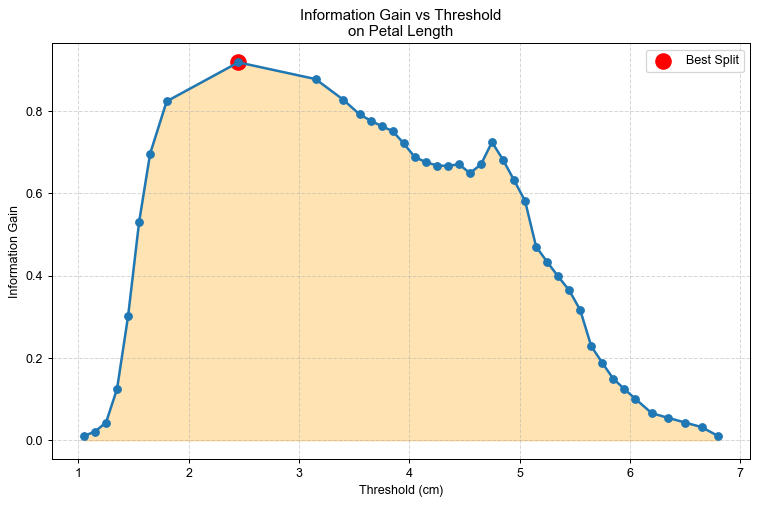

In [5]:
import matplotlib.pyplot as plt

# 准备数据
X = df[iris.feature_names].values
y = iris.target
feat_idx = iris.feature_names.index('petal length (cm)')
values = np.unique(X[:, feat_idx])
thresholds = (values[:-1] + values[1:]) / 2  # 中点作为候选阈值

# 计算信息增益
ig_list = [information_gain(X, y, feat_idx, t) for t in thresholds]

# 绘制
plt.figure(figsize=(10,6))
plt.plot(thresholds, ig_list, marker='o', linewidth=2)
plt.xlabel('Threshold (cm)')
plt.ylabel('Information Gain')
plt.title('Information Gain vs Threshold\non Petal Length')
plt.grid(True, linestyle='--', alpha=0.5)
plt.fill_between(thresholds, ig_list, color='orange', alpha=0.3)
plt.scatter(thresholds[np.argmax(ig_list)], max(ig_list), s=150, color='red', label='Best Split')
plt.legend()
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_007.png)

- 横轴为候选阈值，纵轴为对应信息增益；
- 曲线的峰值点即最优阈值（最大化熵下降）；

### 算法优化

在大规模数据或高维情况下，上述逐阈值循环计算会较慢，我们可以做如下优化：

1. **向量化统计**：用 `np.argsort` 对特征排序，一次性计算所有可能的划分点的左右计数。
2. **增量式熵更新**：当阈值在排序后依次移动时，只需更新从左到右的一个样本类别计数，无需每次都重新扫描左右子集。

In [6]:
def fast_best_split(X_col, y):
    """
    向量化求单特征 X_col 最优划分点及对应信息增益
    返回: (best_threshold, best_ig)
    """
    # 排序
    sorted_idx = np.argsort(X_col)
    Xs, Ys = X_col[sorted_idx], y[sorted_idx]
    # 全局熵
    H_parent = entropy(Ys)
    n = len(Ys)
    
    # 初始化左/右计数
    unique_classes = np.unique(Ys)
    left_count = np.zeros(unique_classes.max()+1, dtype=int)
    right_count = np.bincount(Ys, minlength=unique_classes.max()+1)
    best_ig, best_t = 0.0, None
    
    # 遍历可能分割点（跳过相同值）
    for i in range(1, n):
        c = Ys[i-1]
        left_count[c] += 1
        right_count[c] -= 1
        if Xs[i] == Xs[i-1]:
            continue
        # 当前阈值
        t = (Xs[i] + Xs[i-1]) / 2
        # 计算左右熵（增量式）
        H_left = -np.sum((left_count/ i) * np.log2(left_count/ i + 1e-9) * (left_count>0))
        H_right = -np.sum((right_count/ (n-i)) * np.log2(right_count/ (n-i) + 1e-9) * (right_count>0))
        ig = H_parent - (i/n)*H_left - ((n-i)/n)*H_right
        if ig > best_ig:
            best_ig, best_t = ig, t
    return best_t, best_ig

best_threshold, best_ig = fast_best_split(X[:, feat_idx], y)
print(f"Optimized Best Threshold: {best_threshold:.3f}, Info Gain: {best_ig:.4f}")

Optimized Best Threshold: 2.450, Info Gain: 0.9183


- 预先排序，O(n log n)；
- 统计向量 `left_count` 与 `right_count`，单次遍历即可增量更新；
- 相比于原来对每个阈值重复计算熵，效率大幅提升。

运行结果：

原文参考输出或命令说明（无需在 Python 内核执行）：

```text
Optimized Best Threshold: 2.450, Info Gain: 0.9183
```

在“花瓣长度”特征上，最优阈值约为 2.45 cm，对应信息增益约 0.9183；

该划分将数据基本按“山鸢尾”与其余两类分离，熵显著下降；

向量化实现的 `fast_best_split` 在大数据规模上效率优势明显。

## 模型分析

### 基于信息增益的优缺点

**优点**：

1. **直观易懂**：信息增益将“划分前后不确定性（熵）的减少量”作为评价指标，概念清晰，容易理解和实现。
2. **有效区分特征**：在类别分布高度不均匀或存在明显分类信号的特征上，信息增益能够迅速识别出“最佳”分割点，从而快速提升模型性能。
3. **理论基础扎实**：来源于香农信息论，具备坚实的数学基础，可推广到连续、离散等多种类型的数据。

**缺点**：

1. **偏向多值特征**：当某个特征取值种类非常多时（如 ID、时间戳、类别编码），划分后每个子集往往较“纯”，熵下降大，导致信息增益偏好这种高基数特征，可能引入过拟合。
2. **计算开销大**：对于连续特征，需要对所有候选阈值逐一计算熵并加权平均；在高维大样本情况下，计算量成倍增长。
3. **不考虑划分样本大小**：仅衡量信息量的变化，而不对“子节点样本数”进行平衡惩罚，可能产生非常不平衡的树结构。

### 与相似算法的对比

| **算法** | **划分度量** | **偏好／缺陷** | **计算复杂度** | **适用场景** |
|-|-|-|-|-|
| **信息增益** | 熵的减少量 | 偏好高基数特征；不平衡划分 | $O(mn\log n)$ | 类别分布清晰、特征较少且连续时效果佳 |
| **信息增益率** | 信息增益 ÷ 特征自身熵 | 修正信息增益偏多值缺陷；可能偏向小分支 | $O(mn\log n)$ | 存在高基数类别特征时优于纯信息增益 |
| **基尼指数** | 1 − ∑ $p_i^2$ | 对多值特征偏好较小；数值上更平滑 | $O(mn\log n)$ | 大规模数据（例如随机森林）中常用，速度略快 |
| **卡方检验** | 卡方统计量 | 偏好类别比例差异大者；需离散化 | $O(mn\log n)$ | 需要对统计显著性有严格要求时 |
| **方差减少** | 划分后目标方差减少 | 专为回归问题设计；不适合分类 | $O(mn\log n)$ | 连续目标变量的回归树场景 |

其中，$m$ 为特征数，$n$ 为样本数；

信息增益率通过除以“特征自身信息量”（即特征熵）来惩罚过多取值；

基尼指数在数值上略逊于信息增益在理论解释力，但在多树集成和大数据场景中，计算更稳定，效率更高。

### 何时优选信息增益，何时考虑其他算法

1. **优选信息增益的场景**

   - 特征多为连续值或类别数较少，且各类别分布较为均衡；
   - 需要对模型的“信息理论意义”有直观解释；
   - 数据量中等，不至于对逐阈值计算造成瓶颈；
   - 对树模型的可解释性要求较高时，信息增益能清晰反映每次划分决策的“熵减少”大小。
2. **应考虑其他算法的场景**

   - **高基数类别特征**：若某些类别型特征取值过多（如用户 ID、序列号等），建议改用**信息增益率**或直接剔除该特征；
   - **大规模数据或实时系统**：在样本量非常大、需快速训练时，**基尼指数**计算更为简单且数值平滑，有时能带来更快的收敛与更稳健的划分；
   - **回归任务**：针对连续目标变量，直接采用**方差减少**作为划分度量更合适；
   - **统计显著性需求**：若希望每次划分都满足一定显著性水平，可使用**卡方检验**进行筛选。

综上，信息增益因其概念清晰、理论扎实而被广泛应用于分类决策树中。但在实际工程中，应结合数据特性（特征基数、样本规模、实时性需求等）灵活选择或替换为增益率、基尼指数、方差减少等度量，才能在精度、效率与可解释性之间取得最优平衡。